# Glucose Forecasting — Merged Pipeline (RF / GB / LSTM / CNN-LSTM)

Merges the tree-based and deep-learning pipelines into one workflow, using a
**walk-forward (expanding-window) split** per patient instead of a single
80/20 cut:

1. Loads and engineers features from the `bigideas` parquet files once.
2. Splits each patient into `N_SPLITS` sequential walk-forward folds
   (`TimeSeriesSplit`) — train window expands, test window always follows it
   in time, no leakage.
3. Builds both a **flat** feature matrix (RF / GB) and a **3-D sequence
   tensor** (LSTM / CNN-LSTM) per fold.
4. Grid search (RF / GB / LSTM / CNN-LSTM, Transformer), cached to disk.
5. Trains all four models per fold, for `full` and `comparable` feature sets,
   at three horizons (15 / 30 / 45 min), and aggregates metrics (mean ± std)
   across folds.
6. Ablation study (run on the final, largest-train fold to keep runtime
   reasonable).
7. Results tables, Clarke Error Grid (pooled across folds), ablation bar plots.


## Section 1 — Imports and Configuration

In [ ]:
import glob
import os
import json
import pickle
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import clarke_error_grid as ceg

warnings.filterwarnings('ignore')

# ---- Paths -------------------------------------------------------------
DATA_PATH    = Path('data')
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Config --------------------------------------------------------------
HORIZONS   = {'15min': 3, '30min': 6, '45min': 9}   # steps ahead (5-min resolution)
SEQ_LENGTH = 12                                     # look-back window for LSTM / CNN-LSTM
N_SPLITS   = 5                                      # walk-forward folds per patient

print('Data path   :', DATA_PATH)
print('Results dir :', RESULTS_DIR)
print('Horizons    :', HORIZONS)
print('Walk-forward folds per patient:', N_SPLITS)


Data path   : C:\Users\HP\OneDrive\Desktop\prediction-of-glucose-levels-in-type1-Diabetes\data\bigideas
Results dir : C:\Users\HP\OneDrive\Desktop\prediction-of-glucose-levels-in-type1-Diabetes\experiments\experiments\results
Horizons    : {'15min': 3, '30min': 6, '45min': 9}
Walk-forward folds per patient: 5


## Section 2 — Load Data and Engineer Features

Shared feature-engineering pipeline used by both the tree-based and
deep-learning branches (previously duplicated in the two separate scripts —
consolidated here so it only runs once).

In [2]:

print("\n[1/9] LOADING DATA...")

file_list = glob.glob(os.path.join(DATA_PATH, "clean_patient_*.parquet"))
if not file_list:
    file_list = glob.glob("bent_*.parquet")
if not file_list:
    raise ValueError("No parquet files found!")

df = pd.concat([pd.read_parquet(f) for f in file_list], ignore_index=True)
df = df.sort_values(['Patient_ID', 'Timestamp']).reset_index(drop=True)
print(f"Loaded: {len(df):,} rows from {df['Patient_ID'].nunique()} patients")
print(f"  Date range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")



[1/9] LOADING DATA...
Loaded: 36,880 rows from 16 patients
  Date range: 2020-02-13 17:20:00 to 2020-07-27 10:35:00


In [3]:
print("\n[2/9] TEMPORAL FEATURES...")

df['Hour']            = df['Timestamp'].dt.hour
df['Minute']          = df['Timestamp'].dt.minute
df['DayOfWeek']       = df['Timestamp'].dt.dayofweek
df['MinFromMidnight'] = df['Hour'] * 60 + df['Minute']
df['Hour_sin']        = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos']        = np.cos(2 * np.pi * df['Hour'] / 24)

print("  Hour, Minute, DayOfWeek, MinFromMidnight, Hour_sin, Hour_cos")



[2/9] TEMPORAL FEATURES...
  Hour, Minute, DayOfWeek, MinFromMidnight, Hour_sin, Hour_cos


In [4]:
print("\n[3/9] INTERPOLATING SENSOR GAPS...")

sensor_cols = [c for c in ['Heart_Rate', 'Accu_Vm', 'EDA', 'Skin_Temp', 'BVP', 'IBI']
               if c in df.columns]
for col in sensor_cols:
    df[col] = (df.groupby('Patient_ID')[col]
                 .transform(lambda x: x.interpolate(method='linear', limit=6)))
print(f"  Interpolated {len(sensor_cols)} sensors: {sensor_cols}")



[3/9] INTERPOLATING SENSOR GAPS...
  Interpolated 5 sensors: ['Heart_Rate', 'EDA', 'Skin_Temp', 'BVP', 'IBI']


In [5]:
print("\n[4/9] FOOD FEATURES...")

food_features_all = [c for c in df.columns if any(
    c.startswith(nutrient) for nutrient in
    ['calorie_', 'total_carb_', 'dietary_fiber_', 'sugar_', 'protein_', 'total_fat_']
)]
food_features_carbs = [c for c in df.columns if c.startswith('total_carb_')]

print(f"  Found {len(food_features_all)} total food features")
print(f"  Found {len(food_features_carbs)} carb-only features")



[4/9] FOOD FEATURES...
  Found 18 total food features
  Found 3 carb-only features


In [6]:
print("\n[5/9] ACTIVITY ROLLING WINDOWS...")

ACT_WINDOWS       = {'30min': 6, '1h': 12, '2h': 24, '4h': 48}
activity_features = []

if 'Acc_Vmu' in df.columns:
    for label, periods in ACT_WINDOWS.items():
        col_mean = f'acc_vmu_mean_{label}'
        col_max  = f'acc_vmu_max_{label}'
        df[col_mean] = (df.groupby('Patient_ID')['Acc_Vmu']
                          .transform(lambda x: x.rolling(window=periods, min_periods=1).mean()))
        df[col_max]  = (df.groupby('Patient_ID')['Acc_Vmu']
                          .transform(lambda x: x.rolling(window=periods, min_periods=1).max()))
        activity_features += [col_mean, col_max]
    print(f"  Created {len(activity_features)} activity features from Acc_Vmu")

print("\n[6/9] PHYSIOLOGICAL VARIABILITY...")

physio_features_all        = []
physio_features_heart_rate = []
physio_features_EDA        = []
physio_features_Skin_Temp  = []
physio_features_BVP        = []
physio_features_IBI        = []

if 'Heart_Rate' in df.columns:
    for label, periods in {'30min': 6, '1h': 12, '2h': 24}.items():
        col = f'hr_std_{label}'
        df[col] = (df.groupby('Patient_ID')['Heart_Rate']
                     .transform(lambda x: x.rolling(window=periods, min_periods=1).std()))
        physio_features_all.append(col)
        physio_features_heart_rate.append(col)

if 'EDA' in df.columns:
    for label, periods in {'30min': 6, '45min': 9, '1h': 12}.items():
        col = f'eda_std_{label}'
        df[col] = (df.groupby('Patient_ID')['EDA']
                     .transform(lambda x: x.rolling(window=periods, min_periods=1).std()))
        physio_features_all.append(col)
        physio_features_EDA.append(col)

if 'BVP' in df.columns:
    for label, periods in {'30min': 6, '1h': 12}.items():
        col = f'bvp_std_{label}'
        df[col] = (df.groupby('Patient_ID')['BVP']
                     .transform(lambda x: x.rolling(window=periods, min_periods=1).std()))
        physio_features_all.append(col)
        physio_features_BVP.append(col)

if 'IBI' in df.columns:
    for label, periods in {'30min': 6, '1h': 12}.items():
        col = f'ibi_std_{label}'
        df[col] = (df.groupby('Patient_ID')['IBI']
                     .transform(lambda x: x.rolling(window=periods, min_periods=1).std()))
        physio_features_all.append(col)
        physio_features_IBI.append(col)

if 'Skin_Temp' in df.columns:
    for label, periods in {'30min': 6, '1h': 12}.items():
        col = f'skin_temp_std_{label}'
        df[col] = (df.groupby('Patient_ID')['Skin_Temp']
                     .transform(lambda x: x.rolling(window=periods, min_periods=1).std()))
        physio_features_all.append(col)
        physio_features_Skin_Temp.append(col)

print(f"  Created {len(physio_features_all)} variability features")



[5/9] ACTIVITY ROLLING WINDOWS...
  Created 8 activity features from Acc_Vmu

[6/9] PHYSIOLOGICAL VARIABILITY...
  Created 12 variability features


In [7]:
print("\n[7/9] GLUCOSE LAG FEATURES...")

lag_features = []
for lag in [1, 2, 3, 6, 12]:
    col = f'glucose_lag_{lag}'
    df[col] = df.groupby('Patient_ID')['Glucose'].shift(lag)
    lag_features.append(col)

df['glucose_roc_1'] = df.groupby('Patient_ID')['Glucose'].diff(1)
df['glucose_roc_6'] = df.groupby('Patient_ID')['Glucose'].diff(6)
lag_features.extend(['glucose_roc_1', 'glucose_roc_6'])
print(f"  Created {len(lag_features)} glucose lag/change features")

print("\n[8/9] BUILDING TARGETS (15 / 30 / 45 MIN AHEAD)...")
for label, periods in HORIZONS.items():
    df[f'Target_{label}'] = df.groupby('Patient_ID')['Glucose'].shift(-periods)
    print(f"  {label}: {periods} steps ahead (5-min resolution)")



[7/9] GLUCOSE LAG FEATURES...
  Created 7 glucose lag/change features

[8/9] BUILDING TARGETS (15 / 30 / 45 MIN AHEAD)...
  15min: 3 steps ahead (5-min resolution)
  30min: 6 steps ahead (5-min resolution)
  45min: 9 steps ahead (5-min resolution)


## Section 3 — Walk-Forward Split (per patient)

Replaces the single 80/20 cut with a proper walk-forward split: for every
patient, `TimeSeriesSplit(n_splits=N_SPLITS)` is applied to their
time-ordered rows. This yields `N_SPLITS` folds where the train window keeps
expanding forward in time and the test window always immediately follows it
— the standard walk-forward evaluation setup for time series (Cerqueira et
al. 2020; Bergmeir & Benítez, 2012), and consistent with how the grid search
already validates RF/GB.

`wf_folds[i]` holds the `(df_train, df_test)` pair for fold `i`. The **last**
fold (`wf_folds[-1]`) has the largest training window and plays the role of
the "final" 80/20-style holdout used for grid search and ablation.

In [8]:
print("\n[9/9] BUILDING WALK-FORWARD FOLDS (per patient)...")

def build_walk_forward_folds(df, n_splits=N_SPLITS):
    """Per-patient TimeSeriesSplit -> list of (df_train, df_test) fold pairs."""
    fold_train_idx = [[] for _ in range(n_splits)]
    fold_test_idx  = [[] for _ in range(n_splits)]

    for pid, group in df.groupby('Patient_ID'):
        group = group.sort_values('Timestamp')
        idx = group.index.values
        if len(idx) < n_splits + 1:
            continue  # not enough rows for this many folds
        tscv = TimeSeriesSplit(n_splits=n_splits)
        for fold_i, (tr, te) in enumerate(tscv.split(idx)):
            fold_train_idx[fold_i].extend(idx[tr])
            fold_test_idx[fold_i].extend(idx[te])

    folds = []
    for fold_i in range(n_splits):
        df_tr = df.loc[fold_train_idx[fold_i]].sort_values(['Patient_ID', 'Timestamp']).reset_index(drop=True)
        df_te = df.loc[fold_test_idx[fold_i]].sort_values(['Patient_ID', 'Timestamp']).reset_index(drop=True)
        folds.append((df_tr, df_te))
    return folds


wf_folds = build_walk_forward_folds(df, N_SPLITS)

for i, (df_tr, df_te) in enumerate(wf_folds):
    print(f"  Fold {i}: train={len(df_tr):,} rows  test={len(df_te):,} rows")

# Final fold = largest train window, used for grid search / ablation
df_train, df_test = wf_folds[-1]
print(f"\n  Final fold (grid search / ablation): train={len(df_train):,}  test={len(df_test):,}")



[9/9] BUILDING WALK-FORWARD FOLDS (per patient)...
  Fold 0: train=6,190 rows  test=6,138 rows
  Fold 1: train=12,328 rows  test=6,138 rows
  Fold 2: train=18,466 rows  test=6,138 rows
  Fold 3: train=24,604 rows  test=6,138 rows
  Fold 4: train=30,742 rows  test=6,138 rows

  Final fold (grid search / ablation): train=30,742  test=6,138


## Section 4 — Feature Groups and Dataset-Building Helpers

Same flat / sequence dataset builders as before, now written as functions of
`(df_train, df_test)` so they can be called once per walk-forward fold.

In [9]:
temporal_features = ['Hour', 'Minute', 'DayOfWeek', 'MinFromMidnight', 'Hour_sin', 'Hour_cos']
# sensor_features   = sensor_cols

all_features = (temporal_features +  food_features_all +
                 activity_features + physio_features_all )
all_features = [f for f in all_features if f in df.columns]

all_features_comparable = (temporal_features +  food_features_carbs +
                             activity_features + physio_features_heart_rate)
all_features_comparable = [f for f in all_features_comparable if f in df.columns]

feature_groups = {
    'physio_only':  physio_features_all,
    'EDA':         physio_features_EDA,
    'heart_rate':  physio_features_heart_rate,
    'BVP':          physio_features_BVP,
    'IBI':         physio_features_IBI,
    'food_only':   food_features_all,
    'carbs_only':   food_features_carbs,
    'activity':     activity_features,
    'comparable':  all_features_comparable,
    'lag':         lag_features,
    'glucose':     ['Glucose'],
    'all':         all_features,
}

print(f"  full features       : {len(all_features)}")
print(f"  comparable features : {len(all_features_comparable)}")


  full features       : 44
  comparable features : 20


In [10]:
def create_3d_sequences(X_scaled, y_series, patient_ids, seq_length=SEQ_LENGTH):
    """Turn a scaled 2-D feature matrix into (n, seq_len, n_features) windows,
    never crossing a patient boundary."""
    patient_ids = np.asarray(patient_ids)
    Xs, ys = [], []
    for i in range(seq_length - 1, len(X_scaled)):
        if patient_ids[i - seq_length + 1] != patient_ids[i]:
            continue
        Xs.append(X_scaled[i - seq_length + 1: i + 1])
        ys.append(y_series.iloc[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def build_flat_datasets(df_tr, df_te, feature_sets):
    """feature_sets: dict[name -> list[feature cols]] -> dict[name][horizon] = {...}"""
    out = {name: {} for name in feature_sets}
    for name, features in feature_sets.items():
        for label in HORIZONS:
            target_col  = f'Target_{label}'
            train_clean = df_tr.dropna(subset=[target_col] + features)
            test_clean  = df_te.dropna(subset=[target_col] + features)
            out[name][label] = {
                'x_train': train_clean[features], 'y_train': train_clean[target_col],
                'x_test':  test_clean[features],  'y_test':  test_clean[target_col],
                'test_df': test_clean,
            }
    return out


def build_seq_datasets(df_tr, df_te, feature_sets):
    """feature_sets: dict[name -> list[feature cols]] -> dict[name][horizon] = {...}"""
    out = {name: {} for name in feature_sets}
    for name, features in feature_sets.items():
        for label in HORIZONS:
            target_col  = f'Target_{label}'
            train_clean = df_tr.dropna(subset=[target_col] + features).reset_index(drop=True)
            test_clean  = df_te.dropna(subset=[target_col] + features).reset_index(drop=True)

            scaler     = StandardScaler()
            X_train_2d = scaler.fit_transform(train_clean[features])
            X_test_2d  = scaler.transform(test_clean[features])

            X_train_3d, y_train = create_3d_sequences(X_train_2d, train_clean[target_col], train_clean['Patient_ID'])
            X_test_3d,  y_test  = create_3d_sequences(X_test_2d,  test_clean[target_col],  test_clean['Patient_ID'])

            out[name][label] = {
                'X_train': X_train_3d, 'y_train': y_train,
                'X_test':  X_test_3d,  'y_test':  y_test,
                'test_df': test_clean.iloc[SEQ_LENGTH - 1:].reset_index(drop=True),
                'scaler':  scaler,
            }
    return out


FEATURE_SETS = {'full': all_features, 'comparable': all_features_comparable}

# Datasets for the final fold (used by grid search and ablation)
dataset_flat_final = build_flat_datasets(df_train, df_test, FEATURE_SETS)
dataset_seq_final  = build_seq_datasets(df_train, df_test, FEATURE_SETS)

print('Final-fold flat datasets:', list(dataset_flat_final.keys()))
print('Final-fold sequence datasets:', list(dataset_seq_final.keys()))


Final-fold flat datasets: ['full', 'comparable']
Final-fold sequence datasets: ['full', 'comparable']


## Section 5 — Model Definitions

`GlucoseLSTM`, `GlucoseCNNLSTM`, the clinical sample-weighting scheme, and the
weighted training loop used by both deep-learning models.

In [12]:
class GlucoseDataset(Dataset):
    def __init__(self, x, y, weights):
        self.x = x
        self.y = y
        self.w = weights

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.w[idx]


class GlucoseLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])


class GlucoseCNNLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2,
                 dropout=0.3, cnn_filters=64, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, kernel_size)
        self.relu  = nn.ReLU()
        self.lstm  = nn.LSTM(cnn_filters, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc    = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])


class GlucoseTransformer(nn.Module):
    """Transformer encoder with multi-head self-attention over the
    look-back window, followed by a linear head on the last time step's
    representation. `hidden_dim` doubles as d_model and must be divisible
    by `nhead`."""

    def __init__(self, input_dim, hidden_dim=64, nhead=4, num_layers=2, dropout=0.3, seq_len=SEQ_LENGTH):
        super().__init__()
        assert hidden_dim % nhead == 0, "hidden_dim must be divisible by nhead"
        self.input_proj    = nn.Linear(input_dim, hidden_dim)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, hidden_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_proj(x) + self.pos_embedding[:, :seq_len, :]
        out = self.transformer_encoder(x)
        return self.fc(out[:, -1, :])


def calculate_clinical_weights(y_true):
    weights = np.ones(len(y_true), dtype=np.float32)
    weights[y_true < 54] = 3.0
    weights[(y_true >= 54) & (y_true < 70)] = 2.5
    weights[(y_true > 180) & (y_true <= 250)] = 1.5
    weights[y_true > 250] = 2.0
    return weights


def train_weighted_lstm(x_train, y_train, sample_weights, input_dim, epochs=100, patience=15,
                          model_class=GlucoseLSTM, **kwargs):
    split = int(len(x_train) * 0.85)
    xt = torch.tensor(x_train[:split])
    yt = torch.tensor(y_train[:split]).unsqueeze(1)
    wt = torch.tensor(sample_weights[:split]).unsqueeze(1)

    xv = torch.tensor(x_train[split:])
    yv = torch.tensor(y_train[split:]).unsqueeze(1)
    wv = torch.tensor(sample_weights[split:]).unsqueeze(1)

    model     = model_class(input_dim=input_dim, **kwargs)
    criterion = nn.MSELoss(reduction='none')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(GlucoseDataset(xt, yt, wt), batch_size=64, shuffle=True)

    best_val_loss    = float('inf')
    best_weights      = None
    patience_counter   = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb, wb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss  = (criterion(preds, yb) * wb).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(xv)
            val_loss  = (criterion(val_preds, yv) * wv).mean().item()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights      = model.state_dict().copy()
            patience_counter   = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model, best_val_loss

## Section 6 — Grid Search

Run once on the **final walk-forward fold** (`dataset_flat_final` /
`dataset_seq_final`, `30min` horizon, `full` feature set) and cached to disk.

- **RF / GB**: exhaustive grid search with `TimeSeriesSplit` CV nested inside
  the fold's training window (Probst et al. 2019 for the grid).
- **LSTM / CNN-LSTM**: `hidden_dim` x learning-rate sweep, scored on the
  model's internal validation split (Kingma & Ba 2015 for the LR range).

In [13]:
GS_PATH = RESULTS_DIR / 'grid_search_results.json'

_RF_GB_PARAM_GRID = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 15, 20],
    'min_samples_leaf':  [1, 2, 4],
}

_DL_PARAM_GRID = {
    'hidden_dim': [32, 64, 128],
    'lr':         [1e-3, 5e-4],
}


def grid_search_tree(model_class, X_train, y_train, sample_weight, param_grid, n_splits=3, **fixed_kwargs):
    """Walk-forward (TimeSeriesSplit) grid search for RF / GB regressors."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    keys = list(param_grid.keys())
    combos = list(product(*[param_grid[k] for k in keys]))

    X_arr = X_train.values if hasattr(X_train, 'values') else X_train
    y_arr = y_train.values if hasattr(y_train, 'values') else y_train
    w_arr = np.asarray(sample_weight)

    best_score, best_params = float('inf'), {}
    for combo in combos:
        params = dict(zip(keys, combo))
        fold_scores = []
        for train_idx, val_idx in tscv.split(X_arr):
            model = model_class(**params, **fixed_kwargs)
            model.fit(X_arr[train_idx], y_arr[train_idx], sample_weight=w_arr[train_idx])
            preds = model.predict(X_arr[val_idx])
            fold_scores.append(np.sqrt(mean_squared_error(y_arr[val_idx], preds)))
        mean_score = float(np.mean(fold_scores))
        if mean_score < best_score:
            best_score, best_params = mean_score, params
    return best_params, best_score


def grid_search_dl(model_class, x_train, y_train, sample_weights, input_dim, param_grid,
                     epochs=30, patience=5):
    """hidden_dim x lr sweep for LSTM / CNN-LSTM / Transformer, scored on internal val split."""
    keys = list(param_grid.keys())
    combos = list(product(*[param_grid[k] for k in keys]))

    best_score, best_params = float('inf'), {}
    for combo in combos:
        params = dict(zip(keys, combo))
        _, val_loss = train_weighted_lstm(
            x_train, y_train, sample_weights, input_dim=input_dim,
            epochs=epochs, patience=patience, model_class=model_class,
            hidden_dim=params['hidden_dim'],
        )
        score = val_loss
        if score < best_score:
            best_score, best_params = score, params
    return best_params, best_score


if GS_PATH.exists():
    with open(GS_PATH) as f:
        gs_results = json.load(f)
    print('Loaded existing grid search results from', GS_PATH)
else:
    print('Running grid search on the final walk-forward fold (30min / full) ...')

    gs_flat = dataset_flat_final['full']['30min']
    gs_w    = calculate_clinical_weights(gs_flat['y_train'].values)

    best_rf_params, best_rf_score = grid_search_tree(
        RandomForestRegressor, gs_flat['x_train'], gs_flat['y_train'], gs_w,
        _RF_GB_PARAM_GRID, n_jobs=-1, random_state=42,
    )
    print(f'  RF best params : {best_rf_params}  (RMSE={best_rf_score:.2f})')

    best_gb_params, best_gb_score = grid_search_tree(
        GradientBoostingRegressor, gs_flat['x_train'], gs_flat['y_train'], gs_w,
        _RF_GB_PARAM_GRID, random_state=42,
    )
    print(f'  GB best params : {best_gb_params}  (RMSE={best_gb_score:.2f})')

    gs_seq   = dataset_seq_final['full']['30min']
    gs_w_seq = calculate_clinical_weights(gs_seq['y_train'])

    best_lstm_params, best_lstm_score = grid_search_dl(
        GlucoseLSTM, gs_seq['X_train'], gs_seq['y_train'], gs_w_seq,
        input_dim=len(all_features), param_grid=_DL_PARAM_GRID,
    )
    print(f'  LSTM best params : {best_lstm_params}  (val loss={best_lstm_score:.4f})')

    best_cnnlstm_params, best_cnnlstm_score = grid_search_dl(
        GlucoseCNNLSTM, gs_seq['X_train'], gs_seq['y_train'], gs_w_seq,
        input_dim=len(all_features), param_grid=_DL_PARAM_GRID,
    )
    print(f'  CNN-LSTM best params : {best_cnnlstm_params}  (val loss={best_cnnlstm_score:.4f})')

    best_transformer_params, best_transformer_score = grid_search_dl(
        GlucoseTransformer, gs_seq['X_train'], gs_seq['y_train'], gs_w_seq,
        input_dim=len(all_features), param_grid=_DL_PARAM_GRID,
    )
    print(f'  Transformer best params : {best_transformer_params}  (val loss={best_transformer_score:.4f})')

    gs_results = {
        'rf':          best_rf_params,
        'gb':          best_gb_params,
        'lstm':        best_lstm_params,
        'cnnlstm':     best_cnnlstm_params,
        'transformer': best_transformer_params,
    }
    with open(GS_PATH, 'w') as f:
        json.dump(gs_results, f, indent=2)
    print('Grid search results saved to', GS_PATH)

print()
print('Best parameters:')
for k, v in gs_results.items():
    print(f'  {k:8s}: {v}')

rf_params = {**gs_results['rf'], 'n_jobs': -1, 'random_state': 42, 'max_features': 'sqrt'}
gb_params = {**gs_results['gb'], 'random_state': 42, 'subsample': 0.8, 'learning_rate': 0.05}

Running grid search on the final walk-forward fold (30min / full) ...
  RF best params : {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 1}  (RMSE=23.26)
  GB best params : {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 4}  (RMSE=24.47)
  LSTM best params : {'hidden_dim': 32, 'lr': 0.001}  (val loss=392.6268)
  CNN-LSTM best params : {'hidden_dim': 128, 'lr': 0.0005}  (val loss=395.7952)
  Transformer best params : {'hidden_dim': 64, 'lr': 0.0005}  (val loss=385.2288)
Grid search results saved to C:\Users\HP\OneDrive\Desktop\prediction-of-glucose-levels-in-type1-Diabetes\experiments\experiments\results\grid_search_results.json

Best parameters:
  rf      : {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 1}
  gb      : {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 4}
  lstm    : {'hidden_dim': 32, 'lr': 0.001}
  cnnlstm : {'hidden_dim': 128, 'lr': 0.0005}
  transformer: {'hidden_dim': 64, 'lr': 0.0005}


## Section 7 — Walk-Forward Training Loop

Trains every model on every fold, for both feature subsets, at all three
horizons, using the hyperparameters from Section 6. Per-fold metrics are kept
so Section 9 can report mean ± std across folds, and per-fold predictions are
pooled for the Clarke Error Grid in Section 10.

In [14]:
def train_eval_tree(model_class, params, x_tr, y_tr, x_te, y_te):
    scaler = StandardScaler().fit(x_tr)
    x_tr_sc = scaler.transform(x_tr)
    x_te_sc = scaler.transform(x_te)

    weights = calculate_clinical_weights(y_tr.values)
    model = model_class(**params)
    model.fit(x_tr_sc, y_tr, sample_weight=weights)
    preds = model.predict(x_te_sc)
    return preds


def train_eval_dl(model_class, best_params, x_tr, y_tr, x_te, input_dim, **train_kwargs):
    weights = calculate_clinical_weights(y_tr)
    model, _ = train_weighted_lstm(
        x_tr, y_tr, weights, input_dim=input_dim,
        model_class=model_class, hidden_dim=best_params['hidden_dim'],
        **train_kwargs,
    )
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(x_te)).numpy().flatten()
    return preds


def metrics_dict(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae':  float(mean_absolute_error(y_true, y_pred)),
        'r2':   float(r2_score(y_true, y_pred)),
        'mape': float(np.mean(np.abs((np.asarray(y_true) - y_pred) / np.asarray(y_true))) * 100),
    }


MODEL_SPECS = {
    'rf':          {'kind': 'tree', 'class': RandomForestRegressor, 'params': rf_params},
    'gb':          {'kind': 'tree', 'class': GradientBoostingRegressor, 'params': gb_params},
    'lstm':        {'kind': 'dl',   'class': GlucoseLSTM,        'params': gs_results['lstm']},
    'cnnlstm':     {'kind': 'dl',   'class': GlucoseCNNLSTM,     'params': gs_results['cnnlstm']},
    'transformer': {'kind': 'dl',   'class': GlucoseTransformer, 'params': gs_results['transformer']},
}

# results[model][subset][horizon] = {'fold_metrics': [...], 'pred_pool': [...], 'true_pool': [...]}
results = {
    m: {s: {h: {'fold_metrics': [], 'pred_pool': [], 'true_pool': []} for h in HORIZONS}
        for s in FEATURE_SETS}
    for m in MODEL_SPECS
}

for fold_i, (df_tr, df_te) in enumerate(wf_folds):
    print(f"\n{'='*70}\nFOLD {fold_i}\n{'='*70}")

    flat_ds = build_flat_datasets(df_tr, df_te, FEATURE_SETS)
    seq_ds  = build_seq_datasets(df_tr, df_te, FEATURE_SETS)

    for subset, features in FEATURE_SETS.items():
        for label in HORIZONS:
            # ---- tree models ----
            f = flat_ds[subset][label]
            for model_name in ['rf', 'gb']:
                spec = MODEL_SPECS[model_name]
                preds = train_eval_tree(spec['class'], spec['params'],
                                          f['x_train'], f['y_train'], f['x_test'], f['y_test'])
                m = metrics_dict(f['y_test'].values, preds)
                bucket = results[model_name][subset][label]
                bucket['fold_metrics'].append(m)
                bucket['pred_pool'].append(preds)
                bucket['true_pool'].append(f['y_test'].values)
                print(f"  [fold {fold_i}] {model_name:8s} {subset:10s} {label:6s} RMSE={m['rmse']:.2f} MAE={m['mae']:.2f}")

            # ---- deep learning models ----
            s = seq_ds[subset][label]
            for model_name in ['lstm', 'cnnlstm', 'transformer']:
                spec = MODEL_SPECS[model_name]
                preds = train_eval_dl(spec['class'], spec['params'],
                                        s['X_train'], s['y_train'], s['X_test'],
                                        input_dim=len(features))
                m = metrics_dict(s['y_test'], preds)
                bucket = results[model_name][subset][label]
                bucket['fold_metrics'].append(m)
                bucket['pred_pool'].append(preds)
                bucket['true_pool'].append(s['y_test'])
                print(f"  [fold {fold_i}] {model_name:8s} {subset:10s} {label:6s} RMSE={m['rmse']:.2f} MAE={m['mae']:.2f}")

with open(RESULTS_DIR / 'results_walk_forward.pkl', 'wb') as f:
    pickle.dump(results, f)
print('\nWalk-forward training complete. Results saved to', RESULTS_DIR / 'results_walk_forward.pkl')


FOLD 0
  [fold 0] rf       full       15min  RMSE=18.93 MAE=14.26
  [fold 0] gb       full       15min  RMSE=19.93 MAE=15.04
  [fold 0] lstm     full       15min  RMSE=19.58 MAE=14.67
  [fold 0] cnnlstm  full       15min  RMSE=19.51 MAE=14.73
  [fold 0] transformer full       15min  RMSE=22.39 MAE=17.77
  [fold 0] rf       full       30min  RMSE=19.04 MAE=14.28
  [fold 0] gb       full       30min  RMSE=20.21 MAE=15.26
  [fold 0] lstm     full       30min  RMSE=19.66 MAE=14.66
  [fold 0] cnnlstm  full       30min  RMSE=19.59 MAE=14.72
  [fold 0] transformer full       30min  RMSE=23.68 MAE=18.20
  [fold 0] rf       full       45min  RMSE=19.49 MAE=14.63
  [fold 0] gb       full       45min  RMSE=21.52 MAE=16.05
  [fold 0] lstm     full       45min  RMSE=19.81 MAE=14.72
  [fold 0] cnnlstm  full       45min  RMSE=19.77 MAE=14.75
  [fold 0] transformer full       45min  RMSE=25.63 MAE=19.95
  [fold 0] rf       comparable 15min  RMSE=19.38 MAE=14.47
  [fold 0] gb       comparable 15min  R

## Section 8 — Ablation Study (final fold)

Retrains each model family per feature group in `feature_groups`, on the
final walk-forward fold only (largest training window), and reports RMSE per
horizon.

In [15]:
def run_ablation_tree(model_class, model_name, best_params, feature_groups, df_tr, df_te):
    ablation_results = {}
    for group_name, features in feature_groups.items():
        ablation_results[group_name] = {}
        for label in HORIZONS:
            target_col  = f'Target_{label}'
            train_clean = df_tr.dropna(subset=[target_col] + features)
            test_clean  = df_te.dropna(subset=[target_col] + features)

            scaler = StandardScaler()
            x_tr = scaler.fit_transform(train_clean[features])
            x_te = scaler.transform(test_clean[features])
            y_tr = train_clean[target_col]
            y_te = test_clean[target_col]
            w    = calculate_clinical_weights(y_tr.values)

            model = model_class(**best_params)
            model.fit(x_tr, y_tr, sample_weight=w)
            preds = model.predict(x_te)
            ablation_results[group_name][label] = float(np.sqrt(mean_squared_error(y_te, preds)))
        print(f"  [{model_name}] {group_name}: " + ", ".join(f"{l}={r:.2f}" for l, r in ablation_results[group_name].items()))
    return ablation_results


def run_ablation_dl(model_class, model_name, best_params, feature_groups, df_tr, df_te, **train_kwargs):
    ablation_results = {}
    for group_name, features in feature_groups.items():
        ablation_results[group_name] = {}
        for label in HORIZONS:
            target_col  = f'Target_{label}'
            train_clean = df_tr.dropna(subset=[target_col] + features).reset_index(drop=True)
            test_clean  = df_te.dropna(subset=[target_col] + features).reset_index(drop=True)

            scaler = StandardScaler()
            X_train_2d = scaler.fit_transform(train_clean[features])
            X_test_2d  = scaler.transform(test_clean[features])

            X_train_3d, y_train = create_3d_sequences(X_train_2d, train_clean[target_col], train_clean['Patient_ID'])
            X_test_3d,  y_test  = create_3d_sequences(X_test_2d,  test_clean[target_col],  test_clean['Patient_ID'])

            preds = train_eval_dl(model_class, best_params, X_train_3d, y_train, X_test_3d, input_dim=len(features), **train_kwargs)
            ablation_results[group_name][label] = float(np.sqrt(mean_squared_error(y_test, preds)))
        print(f"  [{model_name}] {group_name}: " + ", ".join(f"{l}={r:.2f}" for l, r in ablation_results[group_name].items()))
    return ablation_results


results_rf_ablation = run_ablation_tree(RandomForestRegressor, 'rf', rf_params, feature_groups, df_train, df_test)
with open(RESULTS_DIR / 'results_rf_ablation.pkl', 'wb') as f:
    pickle.dump(results_rf_ablation, f)

results_gb_ablation = run_ablation_tree(GradientBoostingRegressor, 'gb', gb_params, feature_groups, df_train, df_test)
with open(RESULTS_DIR / 'results_gb_ablation.pkl', 'wb') as f:
    pickle.dump(results_gb_ablation, f)

results_lstm_ablation = run_ablation_dl(GlucoseLSTM, 'lstm', gs_results['lstm'], feature_groups, df_train, df_test)
with open(RESULTS_DIR / 'results_lstm_ablation.pkl', 'wb') as f:
    pickle.dump(results_lstm_ablation, f)

results_cnnlstm_ablation = run_ablation_dl(GlucoseCNNLSTM, 'cnnlstm', gs_results['cnnlstm'], feature_groups, df_train, df_test)
with open(RESULTS_DIR / 'results_cnnlstm_ablation.pkl', 'wb') as f:
    pickle.dump(results_cnnlstm_ablation, f)


  [rf] physio_only: 15min=25.17, 30min=25.15, 45min=25.13
  [rf] EDA: 15min=25.48, 30min=25.62, 45min=25.72
  [rf] heart_rate: 15min=25.70, 30min=25.80, 45min=25.93
  [rf] BVP: 15min=25.82, 30min=25.90, 45min=25.91
  [rf] IBI: 15min=25.63, 30min=25.72, 45min=25.78
  [rf] food_only: 15min=23.16, 30min=22.95, 45min=23.10
  [rf] carbs_only: 15min=24.09, 30min=23.86, 45min=24.04
  [rf] activity: 15min=25.05, 30min=25.03, 45min=24.99
  [rf] comparable: 15min=22.96, 30min=22.72, 45min=22.80
  [rf] lag: 15min=8.16, 30min=15.54, 45min=19.59
  [rf] glucose: 15min=10.67, 30min=17.03, 45min=20.33
  [rf] all: 15min=21.98, 30min=21.77, 45min=22.11
  [gb] physio_only: 15min=25.88, 30min=25.69, 45min=25.76
  [gb] EDA: 15min=25.59, 30min=25.71, 45min=25.89
  [gb] heart_rate: 15min=25.98, 30min=26.21, 45min=26.27
  [gb] BVP: 15min=26.14, 30min=26.39, 45min=26.38
  [gb] IBI: 15min=25.79, 30min=25.92, 45min=25.98
  [gb] food_only: 15min=23.58, 30min=23.03, 45min=23.25
  [gb] carbs_only: 15min=24.70, 30mi

## Section 9 — Results Summary Table

Mean ± std RMSE / MAE / R² / MAPE across the `N_SPLITS` walk-forward folds,
per model, feature subset, and horizon.

In [16]:
rows = []
for model_name, subsets in results.items():
    for subset, horizons in subsets.items():
        for label, bucket in horizons.items():
            fm = pd.DataFrame(bucket['fold_metrics'])
            rows.append({
                'model': model_name, 'subset': subset, 'horizon': label,
                'rmse_mean': fm['rmse'].mean(), 'rmse_std': fm['rmse'].std(),
                'mae_mean':  fm['mae'].mean(),  'mae_std':  fm['mae'].std(),
                'r2_mean':   fm['r2'].mean(),
                'mape_mean': fm['mape'].mean(),
                'n_folds':   len(fm),
            })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(RESULTS_DIR / 'summary_metrics_walk_forward.csv', index=False)

sep = '=' * 78
print(sep)
print(f'WALK-FORWARD SUMMARY  (mean +/- std over {N_SPLITS} folds)')
print(sep)
for label in ['15min', '30min', '45min']:
    print(f'  Horizon: {label}')
    sub = summary_df[summary_df['horizon'] == label]
    for model_name in MODEL_SPECS:
        m = sub[sub['model'] == model_name]
        for _, r in m.iterrows():
            print(f"    {model_name:8s} [{r['subset']:10s}]  "
                  f"RMSE={r['rmse_mean']:.2f}+/-{r['rmse_std']:.2f}  "
                  f"MAE={r['mae_mean']:.2f}+/-{r['mae_std']:.2f}  "
                  f"R2={r['r2_mean']:.4f}  MAPE={r['mape_mean']:.2f}%")
    print()

summary_df.head(20)


WALK-FORWARD SUMMARY  (mean +/- std over 5 folds)
  Horizon: 15min
    rf       [full      ]  RMSE=20.20+/-1.68  MAE=14.59+/-0.63  R2=0.1887  MAPE=12.67%
    rf       [comparable]  RMSE=21.12+/-1.40  MAE=15.41+/-0.58  R2=0.1141  MAPE=13.37%
    gb       [full      ]  RMSE=20.76+/-1.49  MAE=15.03+/-0.55  R2=0.1397  MAPE=13.00%
    gb       [comparable]  RMSE=22.09+/-0.58  MAE=16.15+/-0.23  R2=0.0175  MAPE=13.96%
    lstm     [full      ]  RMSE=22.75+/-1.98  MAE=16.76+/-1.28  R2=-0.0294  MAPE=14.63%
    lstm     [comparable]  RMSE=23.35+/-2.37  MAE=17.58+/-1.74  R2=-0.0835  MAPE=15.32%
    cnnlstm  [full      ]  RMSE=22.48+/-1.96  MAE=16.59+/-1.44  R2=-0.0057  MAPE=14.54%
    cnnlstm  [comparable]  RMSE=22.58+/-2.18  MAE=16.75+/-1.33  R2=-0.0101  MAPE=14.78%
    transformer [full      ]  RMSE=23.65+/-2.45  MAE=17.51+/-1.30  R2=-0.1166  MAPE=15.33%
    transformer [comparable]  RMSE=23.96+/-1.08  MAE=17.62+/-0.40  R2=-0.1532  MAPE=15.50%

  Horizon: 30min
    rf       [full      ]  RMSE=2

,model,subset,horizon,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,mape_mean,n_folds
0,rf,full,15min,20.199368,1.681952,14.587205,0.626610,0.188730,12.671827,5
1,rf,full,30min,20.172957,1.534340,14.644288,0.667470,0.190161,12.761027,5
2,rf,full,45min,20.517624,1.533513,14.921286,0.678566,0.164876,13.037671,5
3,rf,comparable,15min,21.118285,1.398501,15.411634,0.578719,0.114056,13.371404,5
4,rf,comparable,30min,21.006538,1.354192,15.368683,0.631737,0.122818,13.369350,5
5,rf,comparable,45min,21.238250,1.425185,15.592113,0.715426,0.107731,13.595946,5
6,gb,full,15min,20.760498,1.488486,15.027764,0.549588,0.139729,13.001349,5
7,gb,full,30min,20.827653,1.349335,15.122007,0.488707,0.133725,13.180232,5
8,gb,full,45min,21.497834,1.371729,15.697800,0.612005,0.076104,13.751605,5
9,gb,comparable,15min,22.093010,0.579068,16.151222,0.226420,0.017462,13.959111,5


## Section 10 — Clarke Error Grid

Predictions are **pooled across all walk-forward folds** before computing the
Clarke Error Grid, giving a more robust zone estimate than a single split.
Plots are saved as interactive HTML files.

In [17]:
def clarke_grid_pooled(results, model, out_dir=RESULTS_DIR):
    for label in ['15min', '30min', '45min']:
        for subset in FEATURE_SETS:
            bucket = results[model][subset][label]
            y_true = np.concatenate(bucket['true_pool'])
            y_pred = np.concatenate(bucket['pred_pool'])

            print(f"--- {label.upper()} {model} {subset.upper()} ZONES (pooled, {N_SPLITS} folds) ---")
            zones = ceg.zone(y_true, y_pred)
            print(zones)

            fig = ceg.plot(y_true, y_pred)
            fig.update_layout(title_text=f'Clarke Error Grid — {model} {subset} — {label.upper()} (pooled walk-forward)')
            fig.write_html(str(out_dir / f'clarke_{model}_{subset}_{label}_pooled.html'))


for model_name in MODEL_SPECS:
    clarke_grid_pooled(results, model_name)


--- 15MIN rf FULL ZONES (pooled, 5 folds) ---
[79.88, 19.39, 0.0, 0.74, 0.0]
--- 15MIN rf COMPARABLE ZONES (pooled, 5 folds) ---
[78.23, 21.04, 0.0, 0.74, 0.0]
--- 30MIN rf FULL ZONES (pooled, 5 folds) ---
[79.64, 19.64, 0.0, 0.72, 0.0]
--- 30MIN rf COMPARABLE ZONES (pooled, 5 folds) ---
[78.01, 21.27, 0.0, 0.72, 0.0]
--- 45MIN rf FULL ZONES (pooled, 5 folds) ---
[78.26, 21.04, 0.0, 0.69, 0.0]
--- 45MIN rf COMPARABLE ZONES (pooled, 5 folds) ---
[77.04, 22.26, 0.0, 0.7, 0.0]
--- 15MIN gb FULL ZONES (pooled, 5 folds) ---
[78.98, 20.37, 0.0, 0.64, 0.0]
--- 15MIN gb COMPARABLE ZONES (pooled, 5 folds) ---
[76.26, 23.07, 0.0, 0.67, 0.0]
--- 30MIN gb FULL ZONES (pooled, 5 folds) ---
[78.32, 21.02, 0.0, 0.66, 0.0]
--- 30MIN gb COMPARABLE ZONES (pooled, 5 folds) ---
[75.05, 24.24, 0.0, 0.71, 0.0]
--- 45MIN gb FULL ZONES (pooled, 5 folds) ---
[76.14, 23.2, 0.0, 0.66, 0.0]
--- 45MIN gb COMPARABLE ZONES (pooled, 5 folds) ---
[73.85, 25.45, 0.0, 0.69, 0.0]
--- 15MIN lstm FULL ZONES (pooled, 5 folds

## Section 11 — Ablation Bar Plot

RMSE per feature group, per horizon, for each model (final fold) — saved as
PNGs.

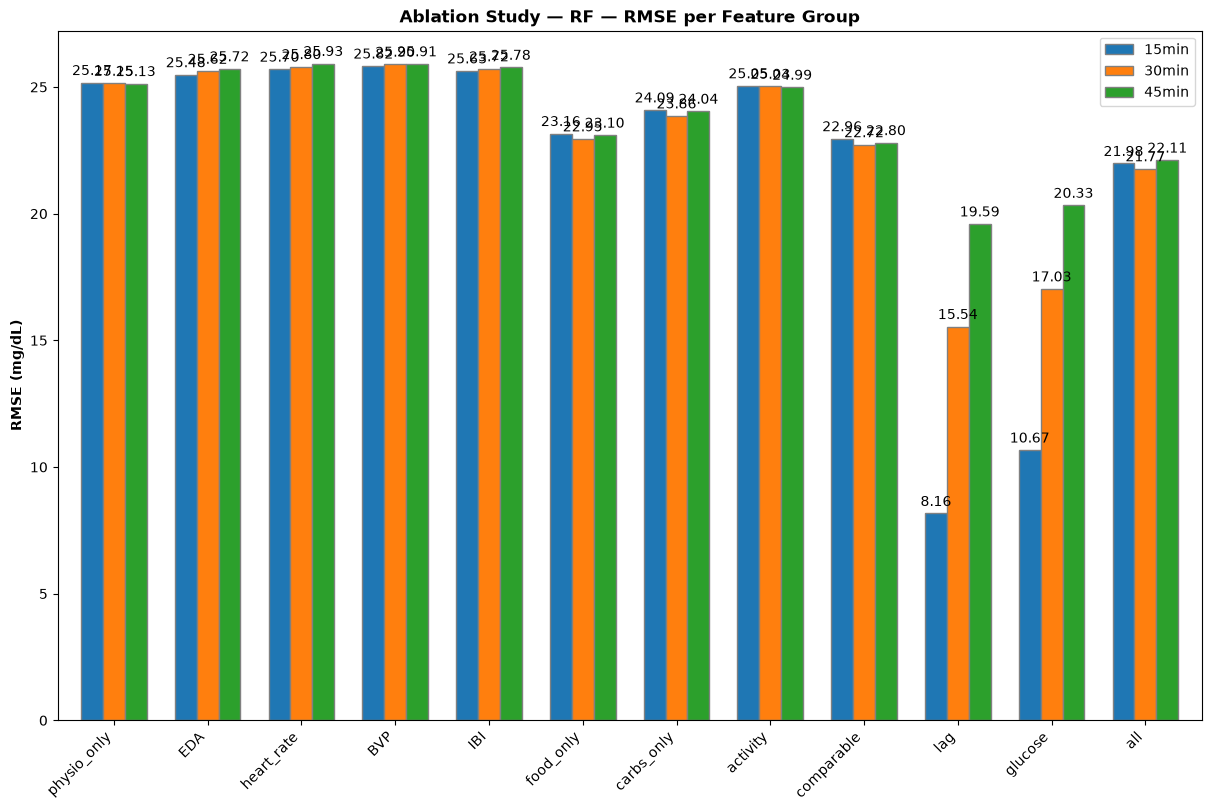

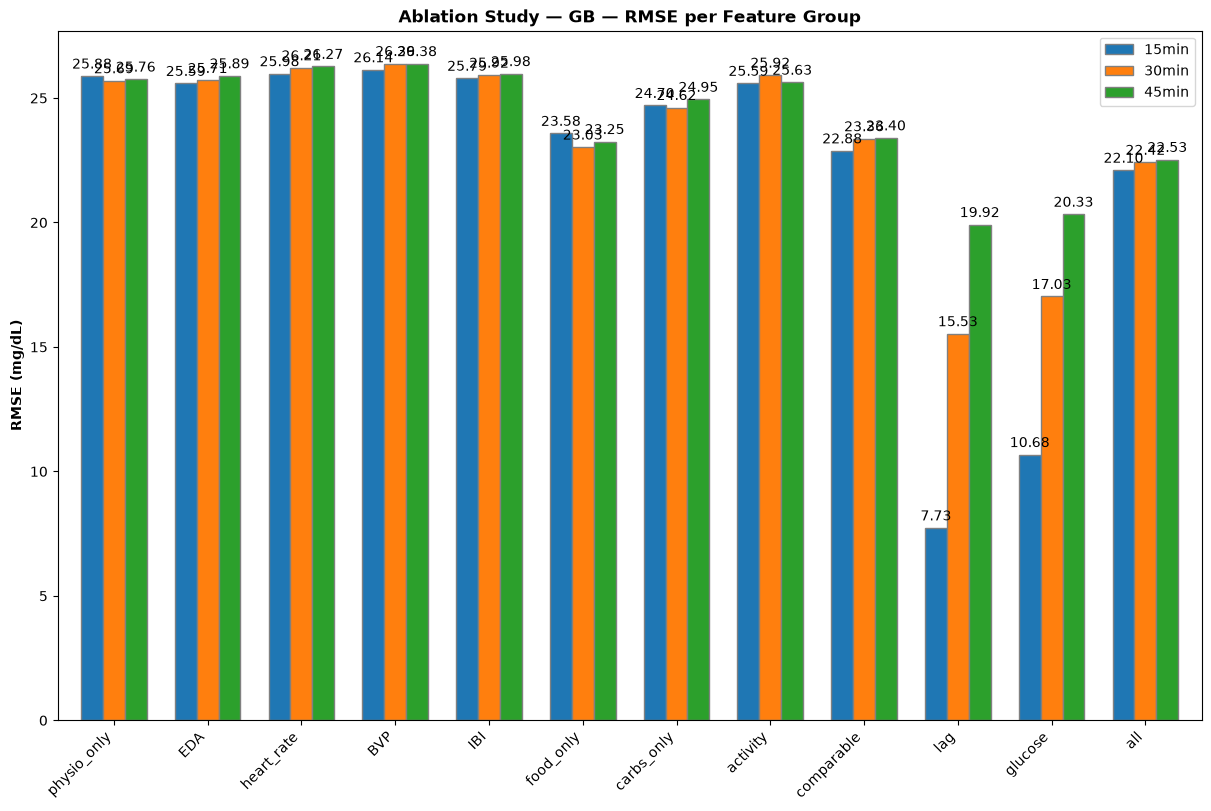

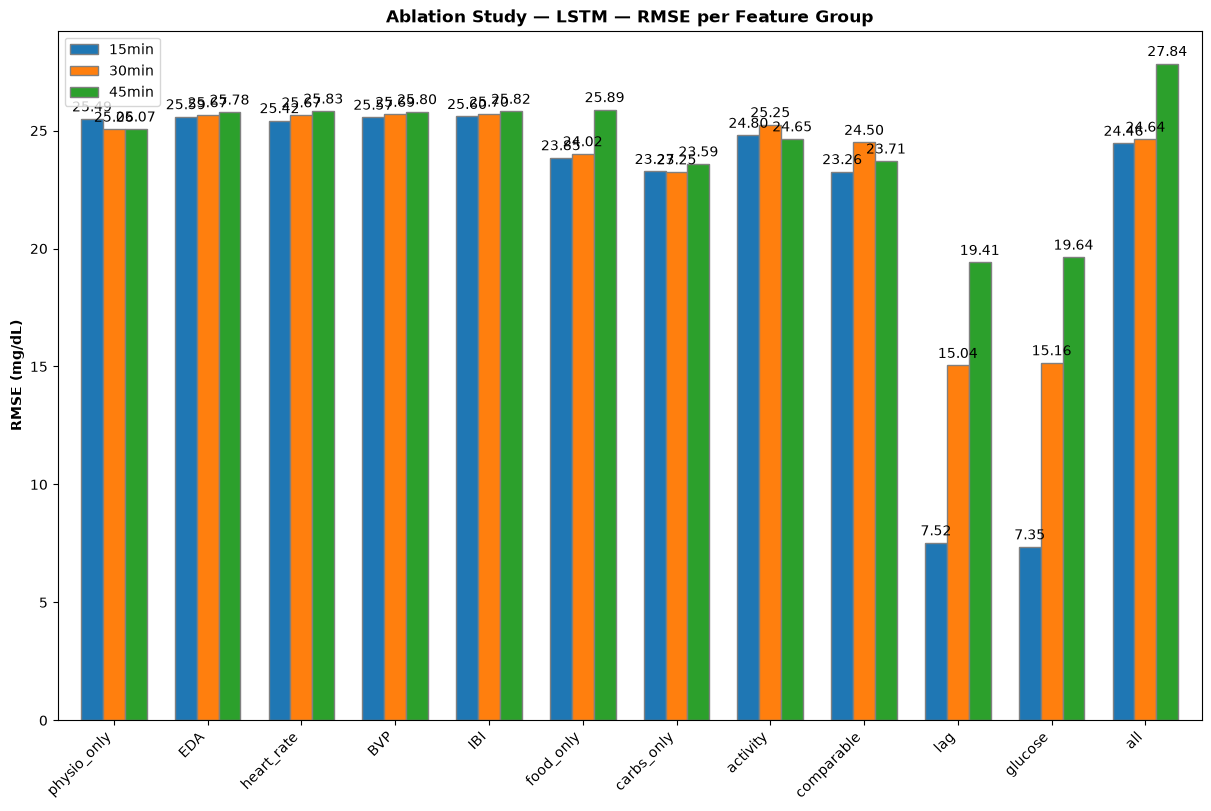

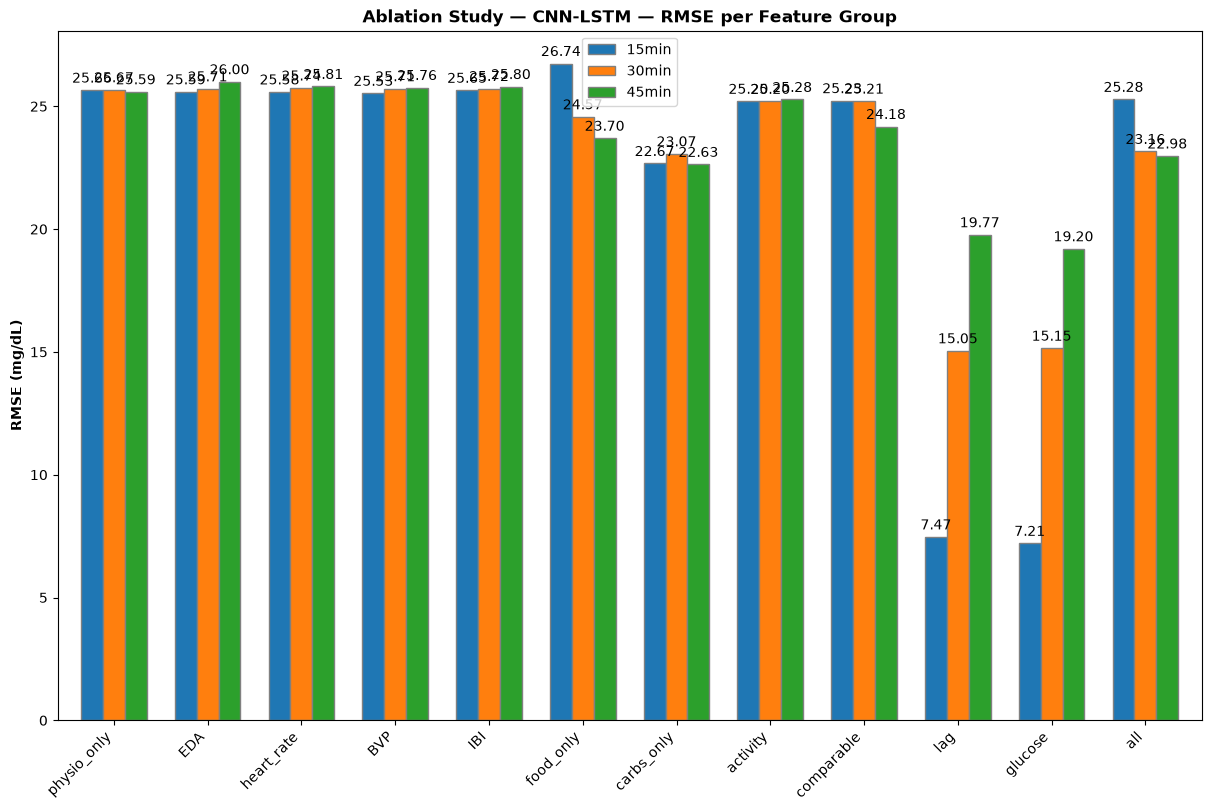

In [20]:
def create_bar_plot(ablation_results, title, save_path):
    df_results = pd.DataFrame(ablation_results).T
    fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
    df_results.plot(kind='bar', ax=ax, width=0.7, edgecolor='grey')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    ax.set_ylabel('RMSE (mg/dL)', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


create_bar_plot(results_rf_ablation,      'Ablation Study — RF — RMSE per Feature Group',      RESULTS_DIR / 'ablation_rf.png')
create_bar_plot(results_gb_ablation,      'Ablation Study — GB — RMSE per Feature Group',      RESULTS_DIR / 'ablation_gb.png')
create_bar_plot(results_lstm_ablation,    'Ablation Study — LSTM — RMSE per Feature Group',    RESULTS_DIR / 'ablation_lstm.png')
create_bar_plot(results_cnnlstm_ablation, 'Ablation Study — CNN-LSTM — RMSE per Feature Group', RESULTS_DIR / 'ablation_cnnlstm.png')
# create_bar_plot(results_transformer_ablation, 'Ablation Study — Transformer — RMSE per Feature Group', RESULTS_DIR / 'ablation_transformer.png')

In [21]:
results_transformer_ablation = run_ablation_dl(
    GlucoseTransformer, 'transformer', gs_results['transformer'], feature_groups, df_train, df_test
)
with open(RESULTS_DIR / 'results_transformer_ablation.pkl', 'wb') as f:
    pickle.dump(results_transformer_ablation, f)

  [transformer] physio_only: 15min=25.24, 30min=26.07, 45min=26.31
  [transformer] EDA: 15min=25.44, 30min=25.49, 45min=25.71
  [transformer] heart_rate: 15min=25.49, 30min=25.35, 45min=25.80
  [transformer] BVP: 15min=25.42, 30min=25.44, 45min=25.51
  [transformer] IBI: 15min=25.44, 30min=25.45, 45min=25.71
  [transformer] food_only: 15min=25.41, 30min=25.63, 45min=23.87
  [transformer] carbs_only: 15min=23.84, 30min=23.11, 45min=23.12
  [transformer] activity: 15min=25.51, 30min=25.51, 45min=25.99
  [transformer] comparable: 15min=26.29, 30min=26.14, 45min=26.19
  [transformer] lag: 15min=7.30, 30min=14.95, 45min=19.24
  [transformer] glucose: 15min=7.93, 30min=15.55, 45min=19.62
  [transformer] all: 15min=26.63, 30min=24.72, 45min=26.70


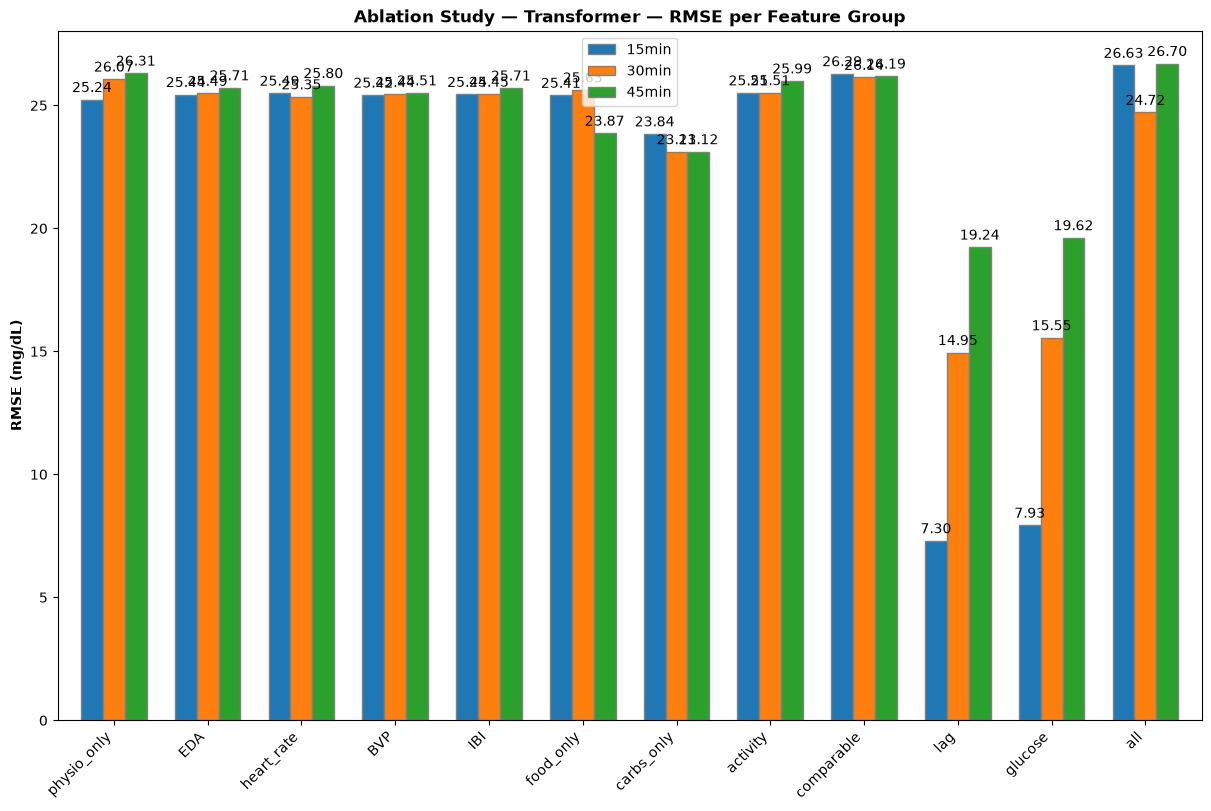

In [22]:
create_bar_plot(results_transformer_ablation, 'Ablation Study — Transformer — RMSE per Feature Group', RESULTS_DIR / 'ablation_transformer.png')